# Predicting Student Academic Performance Using Multivariate Regression Analysis

## Problem Statement

Early identification of students who may struggle academically allows educators to provide timely support and improve learning outcomes. Academic performance is influenced by several factors including study habits, attendance, previous academic achievement, stress levels, sleep patterns, and access to academic support.

This project develops a multivariate regression model that predicts students' examination scores using behavioural, academic, and lifestyle variables. Multiple regression algorithms are compared to identify the best-performing model, which is later prepared for deployment through FastAPI and integration into a Flutter application.

## Project Objectives

The objectives of this project are to:

- Explore and understand the dataset.
- Perform exploratory data analysis using meaningful visualizations.
- Engineer and preprocess features for regression modelling.
- Convert categorical variables into numerical representations.
- Standardize input features before model training.
- Train and compare multiple regression algorithms.
- Optimize a regression model using stochastic gradient descent.
- Evaluate model performance using regression metrics.
- Plot training and testing loss curves.
- Save the best-performing model for deployment.

## Importing Required Libraries

The following libraries are imported to perform data manipulation, visualization, preprocessing, model training, evaluation, and model persistence.

In [77]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import joblib
import kagglehub

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

## Downloading the Dataset

The dataset is downloaded directly from Kaggle using KaggleHub to ensure the notebook is fully reproducible without requiring manual downloads.

In [78]:
dataset_path = kagglehub.dataset_download(
    "aryan208/student-habits-and-academic-performance-dataset"
)

dataset_path

'C:\\Users\\a\\.cache\\kagglehub\\datasets\\aryan208\\student-habits-and-academic-performance-dataset\\versions\\1'

## Locating the Dataset File

The downloaded directory may contain multiple files. The following code identifies all CSV files available in the downloaded dataset.

In [79]:
csv_files = list(Path(dataset_path).rglob("*.csv"))

csv_files

[WindowsPath('C:/Users/a/.cache/kagglehub/datasets/aryan208/student-habits-and-academic-performance-dataset/versions/1/enhanced_student_habits_performance_dataset/enhanced_student_habits_performance_dataset.csv')]

## Loading the Dataset

The first CSV file in the downloaded dataset is loaded into a Pandas DataFrame.

In [80]:
if not csv_files:
    raise FileNotFoundError(
        "No CSV file was found in the downloaded dataset."
    )

df = pd.read_csv(csv_files[0])
df.head()

,student_id,age,gender,major,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,previous_gpa,semester,stress_level,dropout_risk,social_activity,screen_time,study_environment,access_to_tutoring,family_income_range,parental_support_level,motivation_level,exam_anxiety_score,learning_style,time_management_score,exam_score
0,100000,26,Male,Computer Science,7.645367,3.0,0.1,Yes,70.3,6.2,Poor,3,Some College,High,6.0,Yes,4.00,5,5.8,No,0,10.9,Co-Learning Group,Yes,High,9,7,8,Reading,3.0,100
1,100001,28,Male,Arts,5.700000,0.5,0.4,No,88.4,7.2,Good,4,PhD,Low,6.8,No,4.00,7,5.8,No,5,8.3,Co-Learning Group,Yes,Low,7,2,10,Reading,6.0,99
2,100002,17,Male,Arts,2.400000,4.2,0.7,No,82.1,9.2,Good,4,High School,Low,5.7,Yes,3.79,4,8.0,No,5,8.0,Library,Yes,High,3,9,6,Kinesthetic,7.6,98
3,100003,27,Other,Psychology,3.400000,4.6,2.3,Yes,79.3,4.2,Fair,3,Master,Medium,8.5,Yes,4.00,6,4.6,No,3,11.7,Co-Learning Group,Yes,Low,5,3,10,Reading,3.2,100
4,100004,25,Female,Business,4.700000,0.8,2.7,Yes,62.9,6.5,Good,6,PhD,Low,9.2,No,4.00,4,5.7,No,2,9.4,Quiet Room,Yes,Medium,9,1,10,Reading,7.1,98


## Dataset Overview

Before building a regression model, it is important to understand the dataset's dimensions, feature types, descriptive statistics, missing values, and duplicate records.

In [81]:
df.shape

(80000, 31)

In [82]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 31 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     80000 non-null  int64  
 1   age                            80000 non-null  int64  
 2   gender                         80000 non-null  str    
 3   major                          80000 non-null  str    
 4   study_hours_per_day            80000 non-null  float64
 5   social_media_hours             80000 non-null  float64
 6   netflix_hours                  80000 non-null  float64
 7   part_time_job                  80000 non-null  str    
 8   attendance_percentage          80000 non-null  float64
 9   sleep_hours                    80000 non-null  float64
 10  diet_quality                   80000 non-null  str    
 11  exercise_frequency             80000 non-null  int64  
 12  parental_education_level       80000 non-null  str    
 1

In [83]:
df.describe(include="all")

,student_id,age,gender,major,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,previous_gpa,semester,stress_level,dropout_risk,social_activity,screen_time,study_environment,access_to_tutoring,family_income_range,parental_support_level,motivation_level,exam_anxiety_score,learning_style,time_management_score,exam_score
count,80000.000000,80000.000000,80000,80000,80000.000000,80000.000000,80000.000000,80000,80000.000000,80000.000000,80000,80000.000000,80000,80000,80000.000000,80000,80000.000000,80000.000000,80000.000000,80000,80000.000000,80000.000000,80000,80000,80000,80000.000000,80000.000000,80000.000000,80000,80000.000000,80000.000000
unique,NaN,NaN,3,6,NaN,NaN,NaN,2,NaN,NaN,3,NaN,5,3,NaN,2,NaN,NaN,NaN,2,NaN,NaN,5,2,3,NaN,NaN,NaN,4,NaN,NaN
top,NaN,NaN,Female,Arts,NaN,NaN,NaN,No,NaN,NaN,Good,NaN,Some College,High,NaN,No,NaN,NaN,NaN,No,NaN,NaN,Dorm,No,Low,NaN,NaN,NaN,Kinesthetic,NaN,NaN
freq,NaN,NaN,26705,13505,NaN,NaN,NaN,40195,NaN,NaN,39935,NaN,16115,26749,NaN,40058,NaN,NaN,NaN,78418,NaN,NaN,16119,40039,26720,NaN,NaN,NaN,20143,NaN,NaN
mean,139999.500000,22.004288,NaN,NaN,4.174388,2.501366,1.997754,NaN,69.967884,7.017418,NaN,3.516587,NaN,NaN,6.804108,NaN,3.602448,4.497338,5.012478,NaN,2.500225,9.673029,NaN,NaN,NaN,5.479438,5.488525,8.508475,NaN,5.499132,89.141350
std,23094.155105,3.745570,NaN,NaN,2.004135,1.445441,1.155992,NaN,17.333015,1.467377,NaN,2.291575,NaN,NaN,1.921579,NaN,0.462876,2.295312,1.953174,NaN,1.704292,2.780869,NaN,NaN,NaN,2.873327,2.867782,1.796411,NaN,2.603534,11.591497
min,100000.000000,16.000000,NaN,NaN,0.000000,0.000000,0.000000,NaN,40.000000,4.000000,NaN,0.000000,NaN,NaN,1.000000,NaN,1.640000,1.000000,1.000000,NaN,0.000000,0.300000,NaN,NaN,NaN,1.000000,1.000000,5.000000,NaN,1.000000,36.000000
25%,119999.750000,19.000000,NaN,NaN,2.800000,1.200000,1.000000,NaN,55.000000,6.000000,NaN,2.000000,NaN,NaN,5.500000,NaN,3.270000,2.000000,3.600000,NaN,1.000000,7.800000,NaN,NaN,NaN,3.000000,3.000000,7.000000,NaN,3.200000,82.000000
50%,139999.500000,22.000000,NaN,NaN,4.125624,2.500000,2.000000,NaN,69.900000,7.000000,NaN,4.000000,NaN,NaN,6.900000,NaN,3.790000,5.000000,5.000000,NaN,2.000000,9.700000,NaN,NaN,NaN,5.000000,5.000000,10.000000,NaN,5.500000,93.000000
75%,159999.250000,25.000000,NaN,NaN,5.500000,3.800000,3.000000,NaN,84.900000,8.000000,NaN,6.000000,NaN,NaN,8.200000,NaN,4.000000,7.000000,6.400000,NaN,4.000000,11.600000,NaN,NaN,NaN,8.000000,8.000000,10.000000,NaN,7.800000,100.000000


In [84]:
pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Data Type": df.dtypes
})

,Missing Values,Data Type
student_id,0,int64
age,0,int64
gender,0,str
major,0,str
study_hours_per_day,0,float64
social_media_hours,0,float64
netflix_hours,0,float64
part_time_job,0,str
attendance_percentage,0,float64
sleep_hours,0,float64


In [85]:
df.duplicated().sum()

np.int64(0)

### Interpretation

The dataset contains a mixture of numerical and categorical variables describing students' academic backgrounds, study habits, and lifestyle characteristics. Missing values and duplicate records are examined before preprocessing to ensure the machine learning models are trained using clean and reliable data.

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to better understand the relationships between student characteristics and examination performance. The visualizations help identify important predictors and guide feature engineering decisions.

## Distribution of Exam Scores

The target variable is visualized to understand how examination scores are distributed across the dataset.

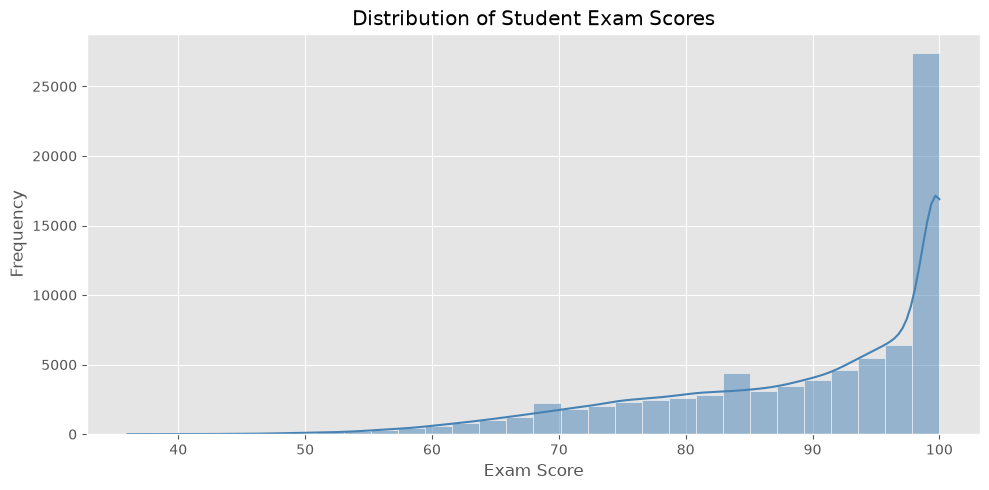

In [86]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="exam_score",
    bins=30,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of Student Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Interpretation

The distribution of examination scores provides insight into the spread of student performance. A relatively balanced distribution indicates that the regression models will learn from students across different achievement levels rather than being dominated by a single score range.

## Correlation Heatmap

The correlation heatmap illustrates the relationships between numerical variables and helps identify factors that are most strongly associated with examination performance.

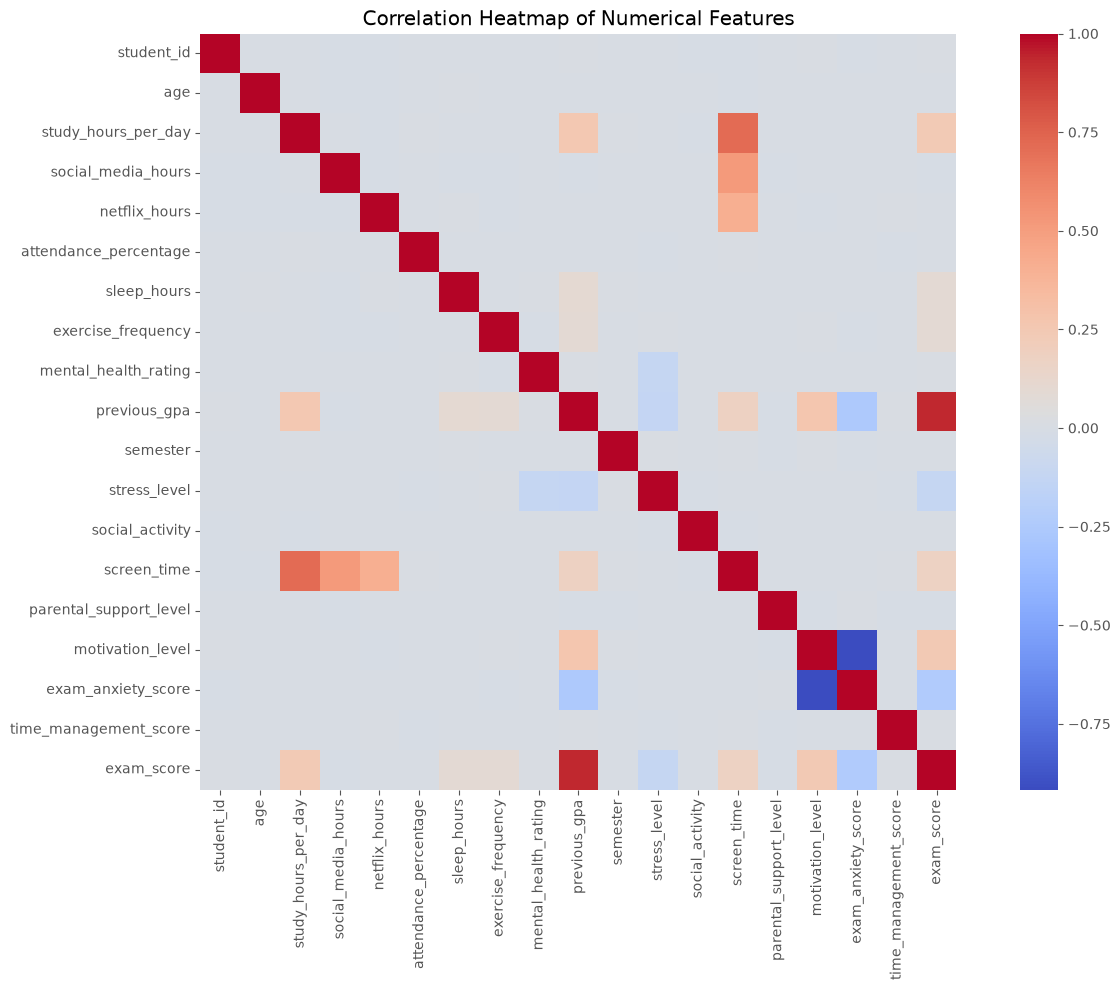

In [87]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(14, 10))

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm",
    annot=False,
    square=True
)

plt.title("Correlation Heatmap of Numerical Features")

plt.tight_layout()
plt.show()

In [88]:
exam_correlation = (
    numeric_df
    .corr()["exam_score"]
    .sort_values(ascending=False)
)

exam_correlation

exam_score                1.000000
previous_gpa              0.932940
motivation_level          0.250287
study_hours_per_day       0.241460
screen_time               0.169788
sleep_hours               0.090820
exercise_frequency        0.086983
mental_health_rating      0.010556
student_id                0.007557
time_management_score     0.005940
attendance_percentage     0.002876
semester                  0.000541
age                       0.000487
netflix_hours            -0.001271
social_activity          -0.002795
parental_support_level   -0.006333
social_media_hours       -0.006351
stress_level             -0.118550
exam_anxiety_score       -0.235909
Name: exam_score, dtype: float64

### Interpretation

The correlation analysis identifies the numerical variables most strongly associated with examination scores. Features such as previous GPA, study hours per day, attendance percentage, and time management score exhibit stronger positive relationships with academic performance and are expected to contribute significantly to the predictive models.

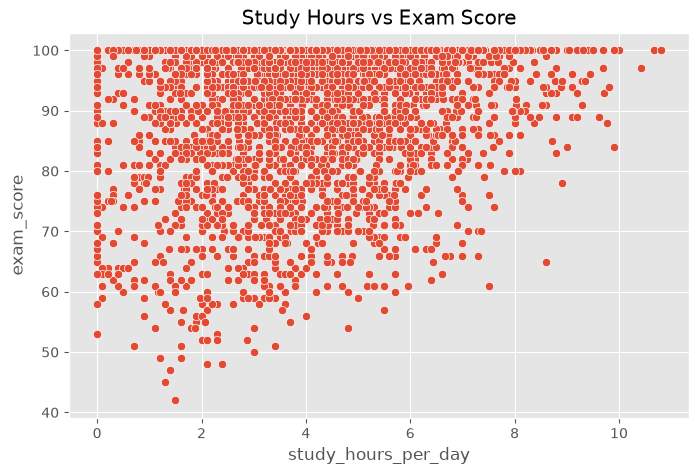

In [89]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df.sample(3000),
    x="study_hours_per_day",
    y="exam_score"
)

plt.title("Study Hours vs Exam Score")

plt.show()

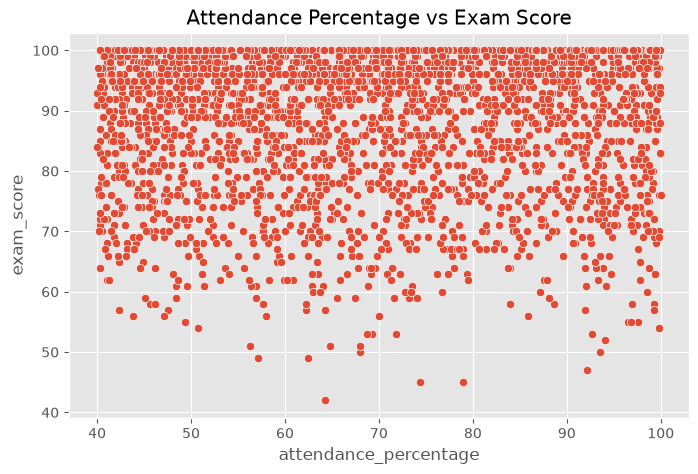

In [90]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df.sample(3000),
    x="attendance_percentage",
    y="exam_score"
)

plt.title("Attendance Percentage vs Exam Score")

plt.show()

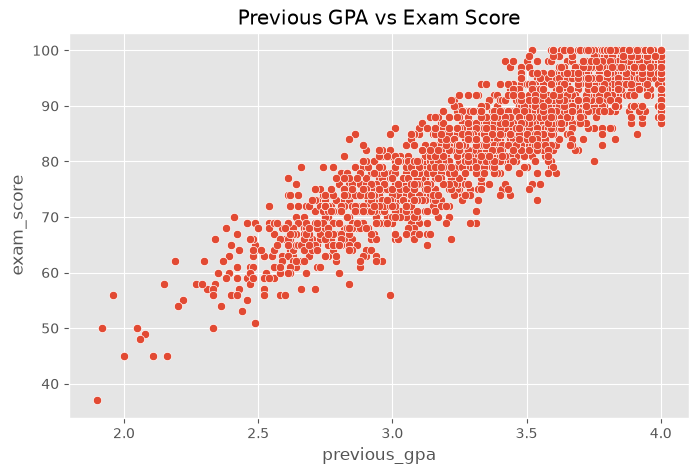

In [91]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df.sample(3000),
    x="previous_gpa",
    y="exam_score"
)

plt.title("Previous GPA vs Exam Score")

plt.show()

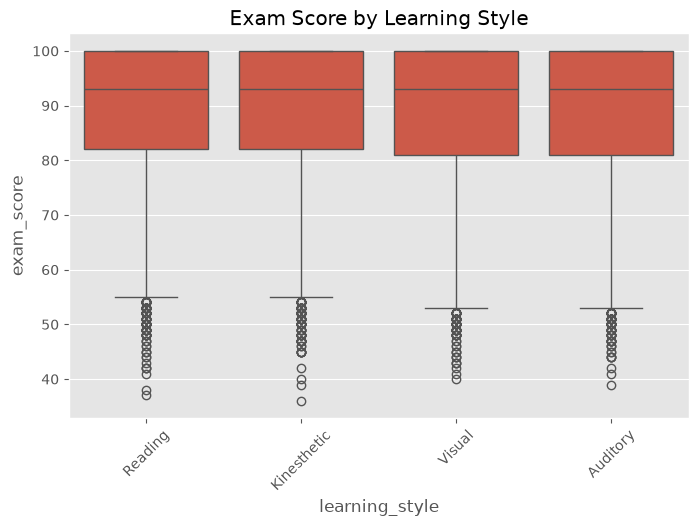

In [92]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="learning_style",
    y="exam_score"
)

plt.xticks(rotation=45)

plt.title("Exam Score by Learning Style")

plt.show()

### Interpretation

Categorical variables such as learning style, study environment, and access to tutoring may influence student performance. These features cannot directly be used by regression algorithms and will require numerical encoding during preprocessing.

# Feature Engineering

Feature engineering prepares the dataset for machine learning by selecting relevant variables, removing unnecessary information, and transforming data into a format suitable for regression algorithms.

The goal is to preserve meaningful educational factors while removing features that could negatively affect model performance or introduce data leakage.

In [93]:
df.duplicated().sum()

np.int64(0)

In [94]:
df = df.drop_duplicates()

df.shape

(80000, 31)

### Interpretation

Duplicate records are removed because repeated observations can cause the model to learn patterns from duplicated data rather than learning general relationships between learning habits and academic performance.

## Removing Irrelevant Features

Some columns do not provide meaningful information for predicting academic performance.

- `student_id` is only an identifier and does not represent a learning factor.
- `dropout_risk` is removed because it may introduce data leakage. It represents a prediction outcome rather than a direct student characteristic.

In [95]:
columns_to_drop = [
    "student_id",
    "dropout_risk"
]

df = df.drop(columns=columns_to_drop)

df.head()

,age,gender,major,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,previous_gpa,semester,stress_level,social_activity,screen_time,study_environment,access_to_tutoring,family_income_range,parental_support_level,motivation_level,exam_anxiety_score,learning_style,time_management_score,exam_score
0,26,Male,Computer Science,7.645367,3.0,0.1,Yes,70.3,6.2,Poor,3,Some College,High,6.0,Yes,4.00,5,5.8,0,10.9,Co-Learning Group,Yes,High,9,7,8,Reading,3.0,100
1,28,Male,Arts,5.700000,0.5,0.4,No,88.4,7.2,Good,4,PhD,Low,6.8,No,4.00,7,5.8,5,8.3,Co-Learning Group,Yes,Low,7,2,10,Reading,6.0,99
2,17,Male,Arts,2.400000,4.2,0.7,No,82.1,9.2,Good,4,High School,Low,5.7,Yes,3.79,4,8.0,5,8.0,Library,Yes,High,3,9,6,Kinesthetic,7.6,98
3,27,Other,Psychology,3.400000,4.6,2.3,Yes,79.3,4.2,Fair,3,Master,Medium,8.5,Yes,4.00,6,4.6,3,11.7,Co-Learning Group,Yes,Low,5,3,10,Reading,3.2,100
4,25,Female,Business,4.700000,0.8,2.7,Yes,62.9,6.5,Good,6,PhD,Low,9.2,No,4.00,4,5.7,2,9.4,Quiet Room,Yes,Medium,9,1,10,Reading,7.1,98


## Separating Features and Target Variable

The target variable for this regression problem is `exam_score`. All remaining selected variables are used as input features to predict student academic performance.

In [96]:
selected_features = [
    "age",
    "gender",
    "major",
    "study_hours_per_day",
    "attendance_percentage",
    "sleep_hours",
    "part_time_job",
    "previous_gpa",
    "stress_level",
    "access_to_tutoring",
    "exam_anxiety_score",
    "time_management_score",
]

X = df[selected_features]
y = df["exam_score"]

In [97]:
X.shape, y.shape

((80000, 12), (80000,))

## Identifying Numerical and Categorical Features

Machine learning algorithms require numerical input. Therefore, categorical variables must be identified so they can be converted into numerical representations during preprocessing.

In [98]:
categorical_features = X.select_dtypes(
    include=["object"]
).columns

numeric_features = X.select_dtypes(
    exclude=["object"]
).columns

categorical_features, numeric_features

(Index(['gender', 'major', 'part_time_job', 'access_to_tutoring'], dtype='str'),
 Index(['age', 'study_hours_per_day', 'attendance_percentage', 'sleep_hours',
        'previous_gpa', 'stress_level', 'exam_anxiety_score',
        'time_management_score'],
       dtype='str'))

## Encoding Categorical Features

Categorical variables are converted into numerical values using One-Hot Encoding. This creates binary indicator variables for each category without introducing artificial numerical relationships between categories.

In [99]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [100]:
X_encoded = preprocessor.fit_transform(X)

X_encoded.shape

(80000, 17)

## Feature Standardization

Standardization scales numerical variables so that features have similar ranges.

This is especially important for gradient descent because large-scale features can dominate the optimization process and slow convergence.

In [101]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X_encoded
)

X_scaled.shape

(80000, 17)

## Splitting the Dataset

The dataset is divided into training and testing sets.

- 80% of the data is used for training.
- 20% is used for evaluating how well the model performs on unseen students.

In [102]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

X_train.shape, X_test.shape

((64000, 17), (16000, 17))

# Training Regression Models

Several regression algorithms are trained and evaluated to determine which model best predicts student examination scores.

Comparing different algorithms provides insight into how model complexity affects predictive performance and helps identify the most suitable model for deployment.

## Initializing Regression Models

Four regression algorithms are selected for comparison:

- **Linear Regression** serves as the baseline model.
- **Decision Tree Regressor** captures nonlinear relationships through recursive data splitting.
- **Random Forest Regressor** combines multiple decision trees to improve predictive performance and reduce overfitting.
- **SGDRegressor** uses stochastic gradient descent to optimize model parameters iteratively and satisfies the project requirement for gradient descent optimization.

In [103]:
models = {
    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),

    "SGD Regression": SGDRegressor(
        random_state=42,
        learning_rate="optimal",
        max_iter=5000
    )
}

## Training the Models

Each regression model is trained using the training dataset. Predictions are then generated using the testing dataset so that each algorithm can be evaluated using the same unseen observations.

In [104]:
model_results = {}

for name, model in models.items():

    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(
        X_test
    )

    model_results[name] = {
        "model": model,
        "predictions": predictions
    }

## Model Evaluation Metrics

The following evaluation metrics are used:

- Mean Absolute Error (MAE):
  Measures the average prediction error.

- Mean Squared Error (MSE):
  Penalizes larger prediction errors.

- Root Mean Squared Error (RMSE):
  Represents error in the same unit as exam scores.

- R² Score:
  Measures how much variation in exam scores is explained by the model.

In [105]:
evaluation_results = []

for name, result in model_results.items():

    predictions = result["predictions"]

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    mse = mean_squared_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_test,
        predictions
    )

    evaluation_results.append(
        [
            name,
            mae,
            mse,
            rmse,
            r2
        ]
    )

In [106]:
results_df = pd.DataFrame(
    evaluation_results,
    columns=[
        "Model",
        "MAE",
        "MSE",
        "RMSE",
        "R2 Score"
    ]
)

results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
)

results_df

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,3.195970,17.539389,4.188005,0.870451
3,SGD Regression,3.206632,17.741975,4.212122,0.868955
2,Random Forest,3.314034,17.935277,4.235006,0.867527
1,Decision Tree,4.498687,36.292063,6.024289,0.731941


### Interpretation

The comparison table summarizes the predictive performance of each regression algorithm. Models with lower MAE, MSE, and RMSE values indicate smaller prediction errors, while a higher R² score indicates a better fit to the data. The highest-performing model will be selected for further optimization and eventual deployment through the FastAPI application.

# Gradient Descent Optimization

SGDRegressor uses stochastic gradient descent to minimize the regression loss function.

Different learning rates and iteration values are tested to identify the configuration that produces the best prediction performance.

In [107]:
sgd_models = {}

learning_rates = [
    "constant",
    "optimal",
    "adaptive"
]

for rate in learning_rates:

    model = SGDRegressor(
        learning_rate=rate,
        eta0=0.01,
        max_iter=5000,
        random_state=42
    )

    model.fit(
        X_train,
        y_train
    )

    prediction = model.predict(
        X_test
    )

    sgd_models[rate] = {
        "model": model,
        "prediction": prediction
    }

In [108]:
sgd_results = []

for rate, result in sgd_models.items():

    prediction = result["prediction"]

    mae = mean_absolute_error(
        y_test,
        prediction
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            prediction
        )
    )

    r2 = r2_score(
        y_test,
        prediction
    )

    sgd_results.append(
        [
            rate,
            mae,
            rmse,
            r2
        ]
    )
sgd_results_df = pd.DataFrame(
    sgd_results,
    columns=[
        "Learning Rate",
        "MAE",
        "RMSE",
        "R2 Score"
    ]
)

sgd_results_df.sort_values(
    by="R2 Score",
    ascending=False
)   

,Learning Rate,MAE,RMSE,R2 Score
2,adaptive,3.195820,4.187994,0.870452
1,optimal,3.206632,4.212122,0.868955
0,constant,3.324418,4.375188,0.858612


## Optimizing the SGDRegressor

After selecting suitable learning rate schedules, additional hyperparameter tuning is performed by evaluating different combinations of learning rates and regularization strengths (`alpha`). The objective is to identify the configuration that produces the highest predictive performance.

In [109]:
from itertools import product

learning_rates = [
    "constant",
    "optimal",
    "adaptive"
]

alphas = [
    0.0001,
    0.001,
    0.01
]

sgd_results = []

best_sgd = None
best_r2 = float("-inf")

for lr, alpha in product(
    learning_rates,
    alphas
):

    model = SGDRegressor(
        learning_rate=lr,
        alpha=alpha,
        eta0=0.01,
        max_iter=5000,
        random_state=42
    )

    model.fit(
        X_train,
        y_train
    )

    prediction = model.predict(
        X_test
    )

    mae = mean_absolute_error(
        y_test,
        prediction
    )

    mse = mean_squared_error(
        y_test,
        prediction
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_test,
        prediction
    )

    sgd_results.append({
        "Learning Rate": lr,
        "Alpha": alpha,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

    if r2 > best_r2:
        best_r2 = r2
        best_sgd = model

sgd_results_df = pd.DataFrame(
    sgd_results
)

sgd_results_df.sort_values(
    by="R2 Score",
    ascending=False
)

,Learning Rate,Alpha,MAE,RMSE,R2 Score
6,adaptive,0.0001,3.195820,4.187994,0.870452
7,adaptive,0.0010,3.196952,4.188111,0.870445
8,adaptive,0.0100,3.209077,4.190729,0.870283
5,optimal,0.0100,3.213027,4.191918,0.870209
4,optimal,0.0010,3.213078,4.193693,0.870099
3,optimal,0.0001,3.206632,4.212122,0.868955
2,constant,0.0100,3.330633,4.373011,0.858753
1,constant,0.0010,3.324753,4.374772,0.858639
0,constant,0.0001,3.324418,4.375188,0.858612


## Training and Testing Loss Curves

The Mean Squared Error (MSE) is recorded after each training epoch to monitor how the SGDRegressor converges over time. Comparing the training and testing losses helps determine whether the model is learning effectively or beginning to overfit.

In [110]:
epochs = 100

loss_train = []
loss_test = []

sgd_curve = SGDRegressor(
    learning_rate="constant",
    eta0=0.001,
    max_iter=1,
    warm_start=True,
    random_state=42
)

for epoch in range(epochs):

    sgd_curve.partial_fit(
        X_train,
        y_train
    )

    train_prediction = sgd_curve.predict(
        X_train
    )

    test_prediction = sgd_curve.predict(
        X_test
    )

    loss_train.append(
        mean_squared_error(
            y_train,
            train_prediction
        )
    )

    loss_test.append(
        mean_squared_error(
            y_test,
            test_prediction
        )
    )

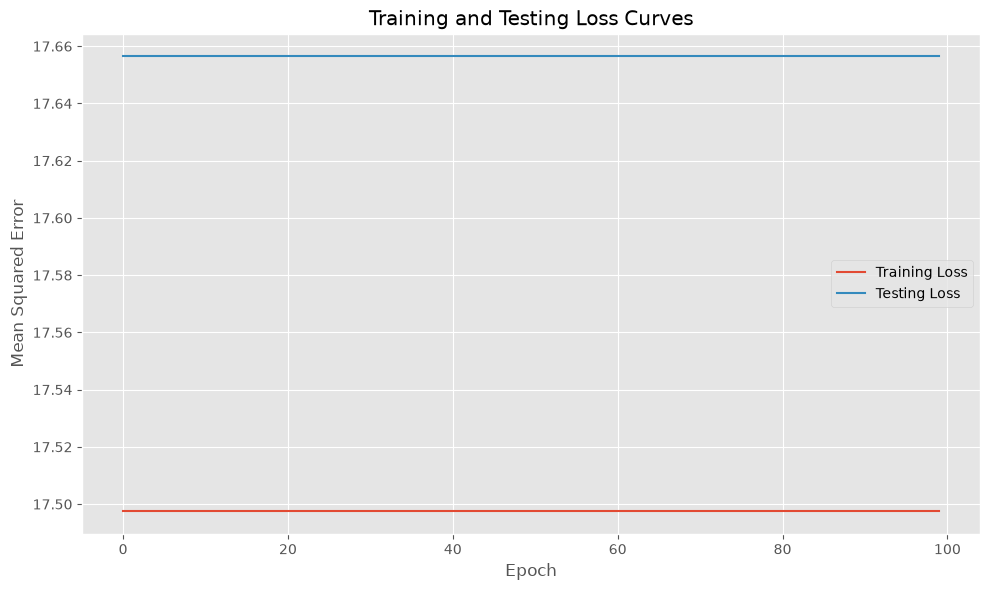

In [111]:
plt.figure(figsize=(10, 6))

plt.plot(
    loss_train,
    label="Training Loss"
)

plt.plot(
    loss_test,
    label="Testing Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("Training and Testing Loss Curves")

plt.legend()

plt.tight_layout()
plt.show()

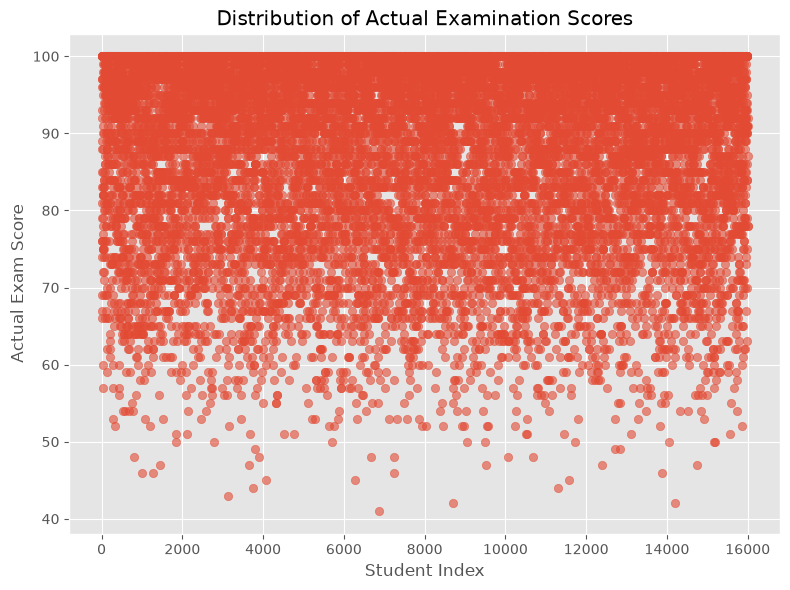

In [112]:
plt.figure(figsize=(8, 6))

plt.scatter(
    range(len(y_test)),
    y_test,
    alpha=0.6
)

plt.xlabel("Student Index")
plt.ylabel("Actual Exam Score")
plt.title("Distribution of Actual Examination Scores")

plt.tight_layout()
plt.show()

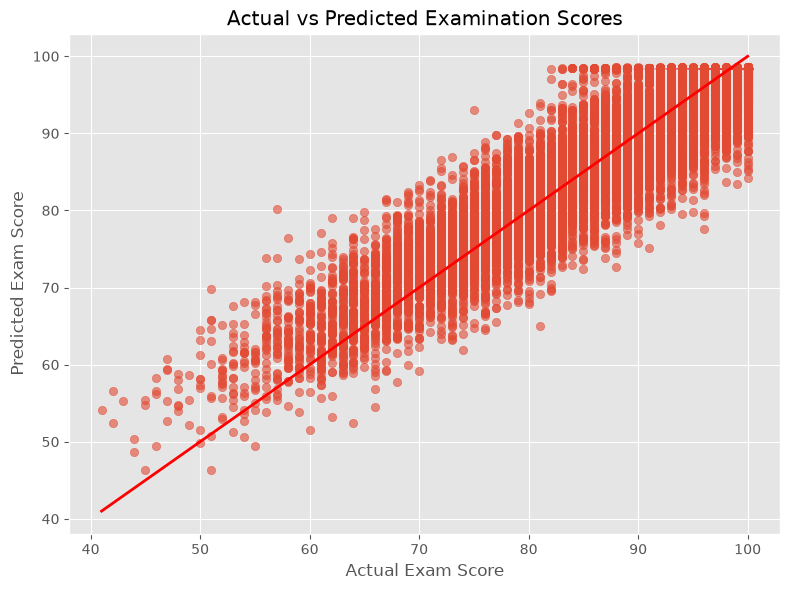

In [113]:
best_model_name = results_df.iloc[0]["Model"]

best_model = model_results[
    best_model_name
]["model"]

predictions = best_model.predict(
    X_test
)

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    predictions,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted Examination Scores")

plt.tight_layout()
plt.show()

In [114]:
MODEL_DIR = Path("models")

MODEL_DIR.mkdir(exist_ok=True)

joblib.dump(best_model, MODEL_DIR / "best_model.pkl")
joblib.dump(scaler, MODEL_DIR / "scaler.pkl")
joblib.dump(preprocessor, MODEL_DIR / "preprocessor.pkl")

list(MODEL_DIR.iterdir())

[WindowsPath('models/best_model.pkl'),
 WindowsPath('models/preprocessor.pkl'),
 WindowsPath('models/scaler.pkl')]